- Name: Shubhajeet Das
- Roll No.: 24AI10013
- DL Lab Assignment - 24 Mar 2026

In [ ]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print(os.listdir())

cuda
['.config', 'data', 'sample_data']


In [ ]:
def show_image(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch
    grid = torchvision.utils.make_grid(images, nrow=3)
    grid = (grid - grid.min()) / (grid.max() - grid.min())
    plt.figure(figsize=(11, 11))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()
    print(labels)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20,lr=1e-3, noise_fn=None, sparse=False):
    print("Starting training...")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running = 0.0
        for batch_idx, (imgs, _) in tqdm(enumerate(train_loader)):
            imgs = imgs.to(device)
            optimizer.zero_grad()

            inp = noise_fn(imgs) if noise_fn else imgs   # corrupt if DAE

            xhat, z = model(inp)
            loss = criterion(xhat, imgs)  # reconstruction loss

            if sparse and hasattr(model, 'kl_loss'):# Extra KL sparsity penalty for Sparse AE
                loss = loss + model.kl_loss(z)

            loss.backward()
            optimizer.step()
            running += loss.item()
            # if batch_idx % 100 == 0:
            #     print(f"  Epoch {epoch+1:2d}/{epochs} | Batch {batch_idx:4d}/{len(train_loader)} | Train Loss: {loss.item():.4f}")

        train_loss = running / len(train_loader)
        train_losses.append(train_loss)

        # ── Validate ──
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                inp  = noise_fn(imgs) if noise_fn else imgs
                xhat, _ = model(inp)
                val_running += criterion(xhat, imgs).item()

        val_loss = val_running / len(val_loader)
        val_losses.append(val_loss)

        print(f"  Epoch {epoch+1:2d}/{epochs} | Train Loss (Avg): {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses,val_losses

# Build a self-supervised learning pipeline using a Convolutional Autoencoder on image data to:

- Learn meaningful representations without labels

- Perform image reconstruction (self-supervision)

- Evaluate learned features using a downstream classification task

## Dataset

Dataset: CIFAR-10

In [ ]:
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((32, 32)),
    # torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize
])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
len(dataset)

50000

In [ ]:
BATCH_SIZE = 64
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_data, val_data, test_data = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
train_loader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## Problem Design

We define a self-supervised task:

- Given a corrupted image → reconstruct the original image

- This forces the model to learn:

	- Spatial structure

	- Object features

	- Texture patterns

## Data Loading & Preprocessing

- Transformations:
	- Normalize
	- Convert to tensor

In [ ]:
# done in previous cell

## Define Corruption Function (SSL Core)


### Type of noise

- Gaussian Noise

- Random Masking

Compare noise vs. Masking



In [ ]:
def gaussian_noise(x, std=0.3):
    noise = torch.randn_like(x) * std
    return (x + noise).clamp(-1.0, 1.0)
def random_mask(x, mask_prob=0.3, mask_value=0.0):
    mask = torch.rand(x.shape, device=x.device) > mask_prob
    return x.where(mask, torch.tensor(mask_value, device=x.device))

### Questions

How does corruption help in self-supervised learning?

Which corruption seems more difficult?

Corruption helps in increasing generalizability of the model, forcing them to understand underlying structures rather than memorising pixel values.

Random mask seems more difficult.

Input Image → Corruption → Encoder → Latent Space → Decoder → Reconstruction

                                      ↓

                              Feature Extraction

                                      ↓

                               Classifier (MLP)

## Autoencoder Architecture

- Implement a Convolutional Autoencoder:
	- Encoder (Conv layers)
	- Latent space (bottleneck)
	- Decoder

## Now here the things get interesting, you can design in one of the two different ways.

1. Transposed Convolution

2. UpSampling + Convolution

Now, what are the pros and cons of these two. Which one will perform in this case.

In [ ]:
class ConvAE_Transposed(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [ ]:
class ConvAE_Upsample(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 16, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 3, 3, stride=1, padding=1),
            nn.ReLU()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [ ]:
convae_t_gauss = ConvAE_Transposed().to(device)
convae_t_rand = ConvAE_Transposed().to(device)
convae_u_gauss = ConvAE_Upsample().to(device)
convae_u_rand = ConvAE_Upsample().to(device)

In [ ]:
EPOCHS = 10

In [ ]:
train_loss_tgauss, val_loss_tgauss = train_model(convae_t_gauss, train_loader, val_loader, epochs=EPOCHS, noise_fn=gaussian_noise)

Starting training...


625it [00:12, 50.25it/s]


  Epoch  1/10 | Train Loss (Avg): 0.6128 | Val Loss: 0.5478


625it [00:12, 51.77it/s]


  Epoch  2/10 | Train Loss (Avg): 0.5332 | Val Loss: 0.5305


...

  Epoch  8/10 | Train Loss (Avg): 0.5105 | Val Loss: 0.5129


625it [00:12, 51.81it/s]


  Epoch  9/10 | Train Loss (Avg): 0.5099 | Val Loss: 0.5124


625it [00:11, 52.10it/s]


  Epoch 10/10 | Train Loss (Avg): 0.5090 | Val Loss: 0.5146


In [ ]:
train_loss_trand, val_loss_trand = train_model(convae_t_rand, train_loader, val_loader, epochs=EPOCHS, noise_fn=random_mask)

Starting training...


625it [00:12, 52.04it/s]


  Epoch  1/10 | Train Loss (Avg): 0.6264 | Val Loss: 0.5762


625it [00:12, 49.35it/s]


  Epoch  2/10 | Train Loss (Avg): 0.5691 | Val Loss: 0.5710


...

  Epoch  8/10 | Train Loss (Avg): 0.5557 | Val Loss: 0.5592


625it [00:12, 51.51it/s]


  Epoch  9/10 | Train Loss (Avg): 0.5552 | Val Loss: 0.5586


625it [00:12, 51.45it/s]


  Epoch 10/10 | Train Loss (Avg): 0.5544 | Val Loss: 0.5578


In [ ]:
train_loss_ugauss, val_loss_ugauss = train_model(convae_u_gauss, train_loader, val_loader, epochs=EPOCHS, noise_fn=gaussian_noise)

Starting training...


625it [00:12, 48.26it/s]


  Epoch  1/10 | Train Loss (Avg): 0.5888 | Val Loss: 0.5517


625it [00:13, 46.97it/s]


  Epoch  2/10 | Train Loss (Avg): 0.5425 | Val Loss: 0.5404


...

  Epoch  8/10 | Train Loss (Avg): 0.5221 | Val Loss: 0.5245


625it [00:12, 48.33it/s]


  Epoch  9/10 | Train Loss (Avg): 0.5214 | Val Loss: 0.5237


625it [00:13, 48.07it/s]


  Epoch 10/10 | Train Loss (Avg): 0.5205 | Val Loss: 0.5239


In [ ]:
train_loss_urand, val_loss_urand = train_model(convae_u_rand, train_loader, val_loader, epochs=EPOCHS, noise_fn=random_mask)

Starting training...


625it [00:12, 48.20it/s]


  Epoch  1/10 | Train Loss (Avg): 0.5628 | Val Loss: 0.5311


625it [00:12, 48.44it/s]


  Epoch  2/10 | Train Loss (Avg): 0.5231 | Val Loss: 0.5257


...

  Epoch  8/10 | Train Loss (Avg): 0.5087 | Val Loss: 0.5119


625it [00:13, 47.33it/s]


  Epoch  9/10 | Train Loss (Avg): 0.5077 | Val Loss: 0.5108


625it [00:12, 48.26it/s]


  Epoch 10/10 | Train Loss (Avg): 0.5067 | Val Loss: 0.5110


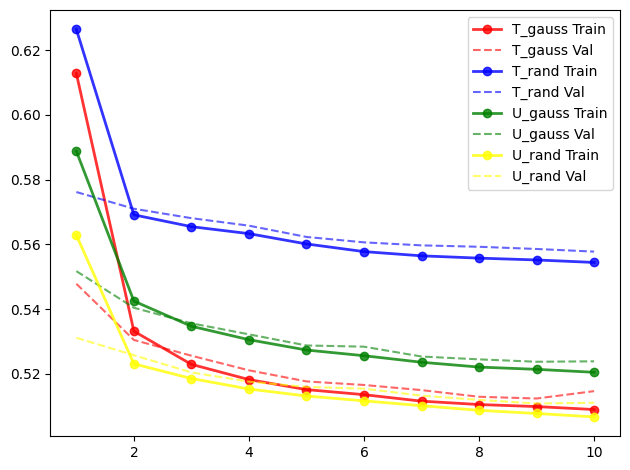

In [ ]:
epochs = range(1, EPOCHS + 1)
plt.plot(epochs, train_loss_tgauss, 'o-', color='red', label=f'T_gauss Train', linewidth=2, alpha=0.8)
plt.plot(epochs, val_loss_tgauss, '--', color='red', label=f'T_gauss Val', linewidth=1.5, alpha=0.6)

plt.plot(epochs, train_loss_trand, 'o-', color='blue', label=f'T_rand Train', linewidth=2, alpha=0.8)
plt.plot(epochs, val_loss_trand, '--', color='blue', label=f'T_rand Val', linewidth=1.5, alpha=0.6)

plt.plot(epochs, train_loss_ugauss, 'o-', color='green', label=f'U_gauss Train', linewidth=2, alpha=0.8)
plt.plot(epochs, val_loss_ugauss, '--', color='green', label=f'U_gauss Val', linewidth=1.5, alpha=0.6)

plt.plot(epochs, train_loss_urand, 'o-', color='yellow', label=f'U_rand Train', linewidth=2, alpha=0.8)
plt.plot(epochs, val_loss_urand, '--', color='yellow', label=f'U_rand Val', linewidth=1.5, alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

### Design the models with both the models and show the comparison to support your statement.

1. Transposed Convolution (Deconvolution)
- Pros: It allows the network to learn the optimal upscaling weights for the specific corruption. It can learn complex, non-linear mappings.
- Cons: Highly prone to checkerboard artifacts. Because the kernel "overlaps" unevenly as it slides, we get a grid-like pattern in the reconstructed image.
    

2. UpSampling + Convolution
- Pros: Effectively eliminates checkerboard artifacts. It produces smoother, more natural transitions. It's often more stable during training.
- Cons: It can result in blurrier images initially because the fixed upsampling doesn't "know" the data; it relies entirely on the subsequent convolution to recover sharp edges.


Random Masking UpSampling + Convolution should perform better.

## Representation Learning

Latent Feature Extraction
- Extract features from encoder
- Flatten latent representation

In [ ]:
def imshow(img, title=None):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")

In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)

with torch.no_grad():
    _, zouts = convae_u_rand(images)

NUM_IMAGES = 5
print("Flattened latent features for the first 5 test images (from Upsampled ConvAE with Random mask encoder):")
for i in range(NUM_IMAGES):
    print(f"Image {i+1} latent features: {zouts[i].flatten().cpu().numpy()}")

Flattened latent features for the first 5 test images (from Upsampled ConvAE with Random mask encoder):
Image 1 latent features: [0.2891113  0.14564018 0.05972275 ... 0.3549983  0.02264098 0.40689552]
Image 2 latent features: [3.0254655 2.4488654 2.1191266 ... 1.0989734 0.7994743 1.0738937]
Image 3 latent features: [0.         0.         0.         ... 0.83569646 0.15399091 0.3917861 ]
Image 4 latent features: [0. 0. 0. ... 0. 0. 0.]
Image 5 latent features: [0.19505495 0.45068005 0.72062576 ... 0.694245   0.         0.17327215]


### Visualization of Reconstruction

Display:

- Original

- Corrupted

- Reconstructed

Visualizing Transposed ConvAE with Gaussian Noise...


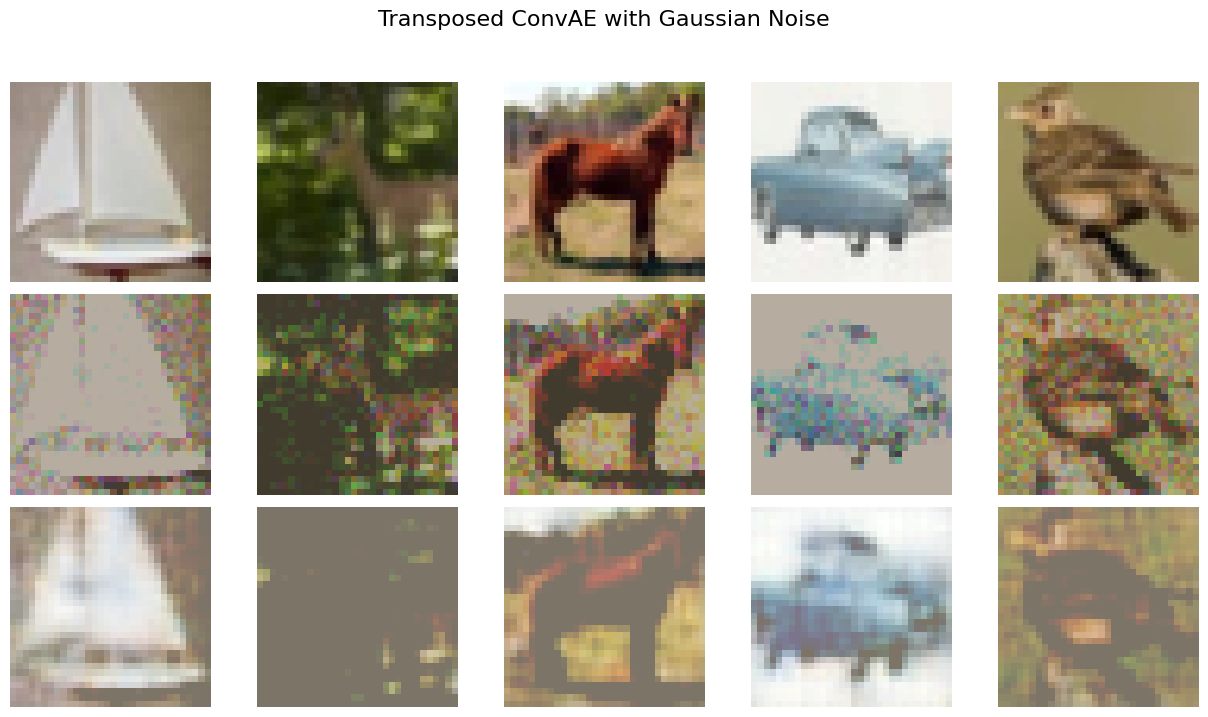

Visualizing Transposed ConvAE with Random Mask...


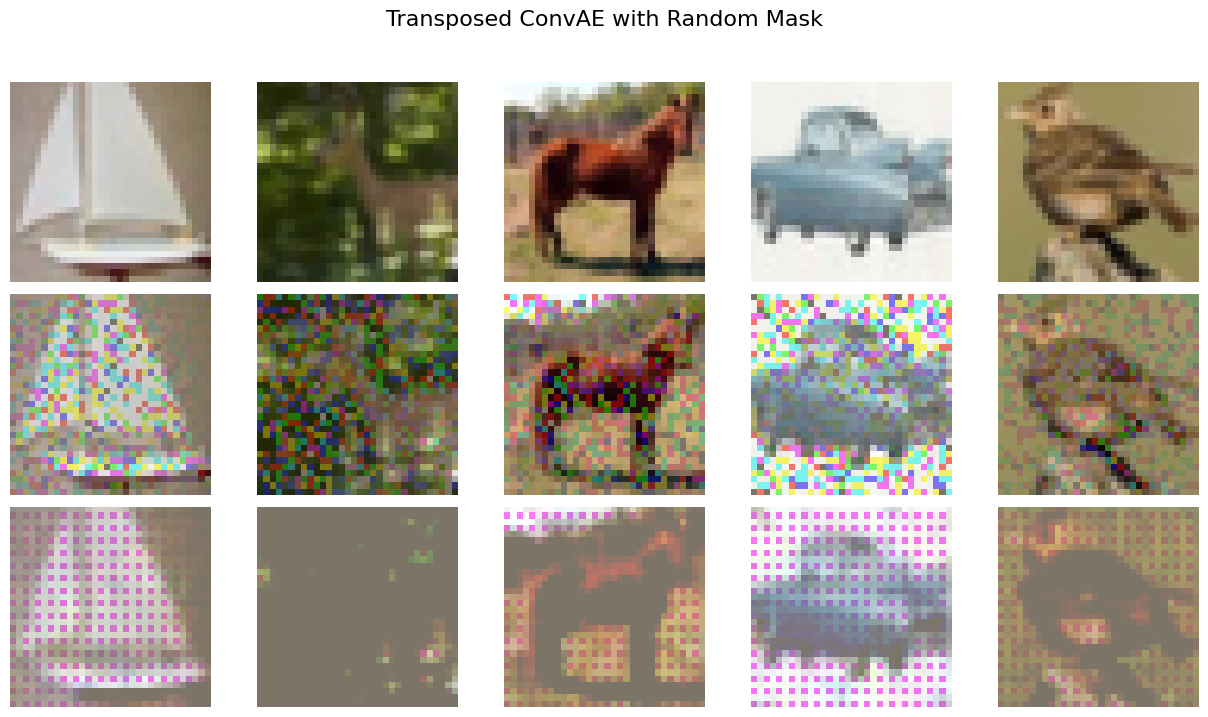

Visualizing Upsample ConvAE with Gaussian Noise...


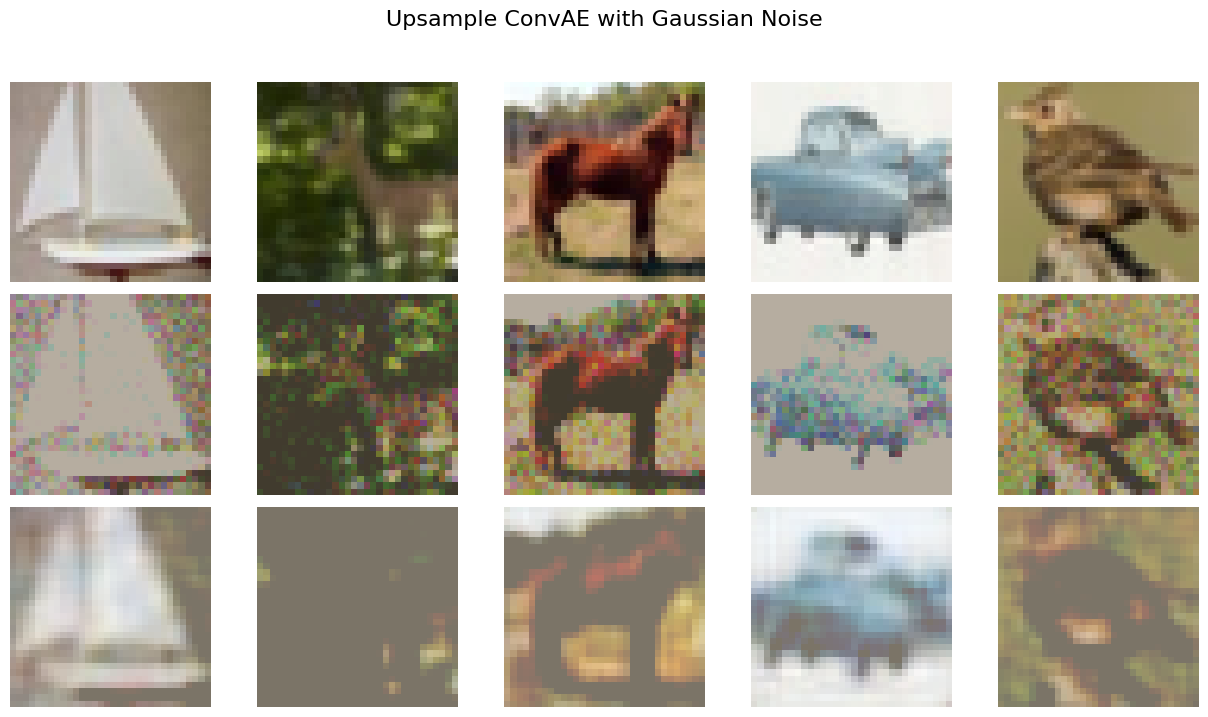

Visualizing Upsample ConvAE with Random Mask...


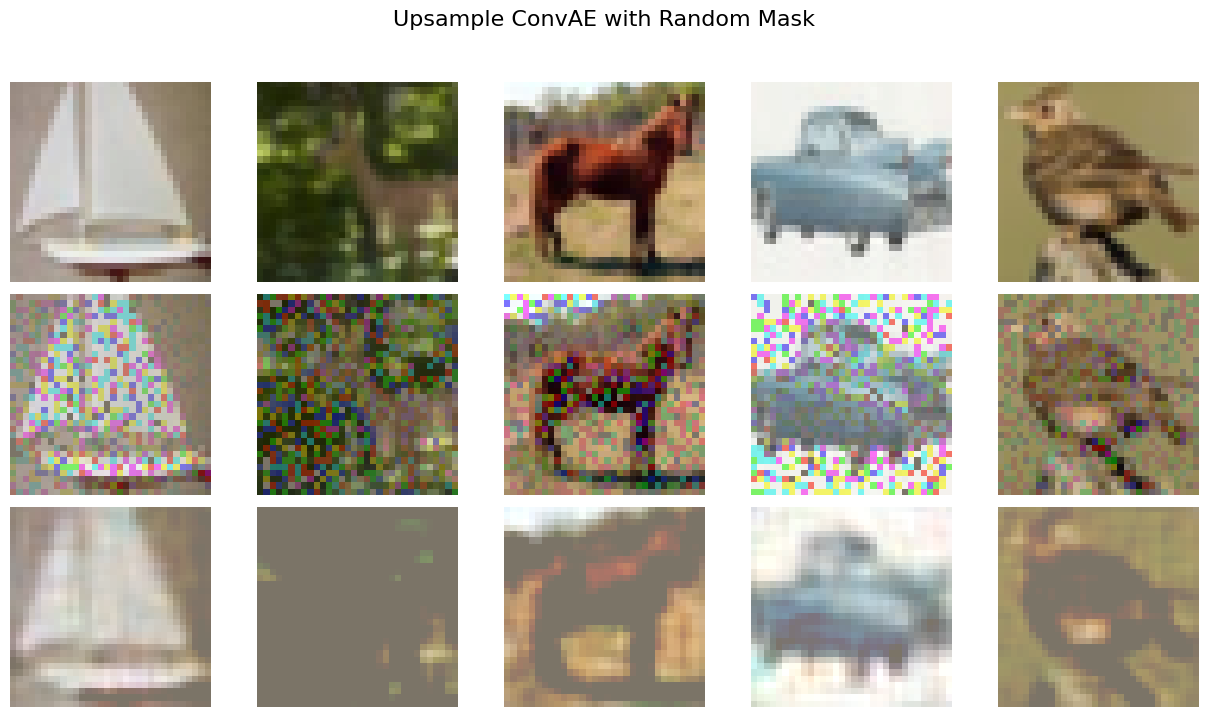

In [ ]:
def visualize_reconstruction(model, noise_fn, data_loader, title_prefix, num_images=6):
    model.eval()
    dataiter = iter(data_loader)
    images, _ = next(dataiter)
    images = images.to(device)

    with torch.no_grad():
        noisy_images = noise_fn(images)
        reconstructed_images, _ = model(noisy_images)

    plt.figure(figsize=(num_images * 2.5, 7.5))
    for i in range(num_images):
        # Original
        plt.subplot(3, num_images, i + 1)
        if i == 0: plt.ylabel("Original", rotation=0, ha="right", fontsize=12)
        imshow(images[i])

        # Corrupted
        plt.subplot(3, num_images, num_images + i + 1)
        if i == 0: plt.ylabel(f"Corrupted", rotation=0, ha="right", fontsize=12)
        imshow(noisy_images[i])

        # Reconstructed
        plt.subplot(3, num_images, 2 * num_images + i + 1)
        if i == 0: plt.ylabel("Reconstructed", rotation=0, ha="right", fontsize=12)
        imshow(reconstructed_images[i])

    plt.suptitle(title_prefix, fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

num_display_images =5

print("Visualizing Transposed ConvAE with Gaussian Noise...")
visualize_reconstruction(convae_t_gauss, gaussian_noise, test_loader, "Transposed ConvAE with Gaussian Noise", num_display_images)

print("Visualizing Transposed ConvAE with Random Mask...")
visualize_reconstruction(convae_t_rand, random_mask, test_loader, "Transposed ConvAE with Random Mask", num_display_images)

print("Visualizing Upsample ConvAE with Gaussian Noise...")
visualize_reconstruction(convae_u_gauss, gaussian_noise, test_loader, "Upsample ConvAE with Gaussian Noise", num_display_images)

print("Visualizing Upsample ConvAE with Random Mask...")
visualize_reconstruction(convae_u_rand, random_mask, test_loader, "Upsample ConvAE with Random Mask", num_display_images)

## Questions

- Which method gives smoother outputs? Why?

- Which method has more learnable parameters? What is the impact?



Upsample ConvAE with Random Mask gives smoother outputs. This is because random masking is helping improve generalizability and upsampling eliminates checkerboard artifacts.

In [ ]:
sum(p.numel() for p in convae_t_rand.parameters() if p.requires_grad)

10147

In [ ]:
sum(p.numel() for p in convae_u_rand.parameters() if p.requires_grad)

10147

Both have same number of learnable parameters.